In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

plt.style.use('ggplot')

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("cleaned_KADIRS_Tax_Compliance.csv")

In [4]:
df.head()

,record_id,taxpayer_id,tin,business_name,owner_name,taxpayer_type,business_sector,lga,registration_date,tax_year,...,penalty,annual_turnover,risk_level,compliance_score,revenue_office,notification_sent,registration_year,registration_month,filing_month,payment_month
0,1,100251,KAD-TIN-202500000,Robinson and Sons,Kayla May,Individual,Ict,Igabi,2024-11-23,2025,...,57314,126908867,High,97,Kaduna North,Yes,2024,November,February,February
1,2,100226,KAD-TIN-202500001,"Conrad, Colon and Wilson",Haley Lewis,Sme,Healthcare,Kaduna North,2025-01-01,2025,...,56443,411897789,Medium,33,Kaduna North,No,2025,January,December,January
2,3,100045,KAD-TIN-202500002,Davidson LLC,Barbara Buckley,Corporate,Manufacturing,Makarfi,2024-02-19,2025,...,18233,26601779,High,49,Kaduna South,Yes,2024,February,September,October
3,4,100285,KAD-TIN-202500003,Burch-Waller,Jon Smith,Sme,Agriculture,Jaba,2025-03-13,2025,...,191136,133431865,Low,79,Kaduna South,No,2025,March,August,August
4,5,100333,KAD-TIN-202500004,"Alvarez, Rodriguez and Bennett",Amanda Gonzalez,Individual,Ict,Chikun,2025-04-18,2025,...,188196,170941402,Low,83,Kaduna South,No,2025,April,April,April


In [5]:
df.shape

(2000, 33)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   record_id            2000 non-null   int64 
 1   taxpayer_id          2000 non-null   int64 
 2   tin                  2000 non-null   object
 3   business_name        2000 non-null   object
 4   owner_name           2000 non-null   object
 5   taxpayer_type        2000 non-null   object
 6   business_sector      2000 non-null   object
 7   lga                  2000 non-null   object
 8   registration_date    2000 non-null   object
 9   tax_year             2000 non-null   int64 
 10  tax_month            2000 non-null   object
 11  tax_type             2000 non-null   object
 12  filing_due_date      2000 non-null   object
 13  filing_date          525 non-null    object
 14  filing_status        2000 non-null   object
 15  amount_assessed      2000 non-null   int64 
 16  amount

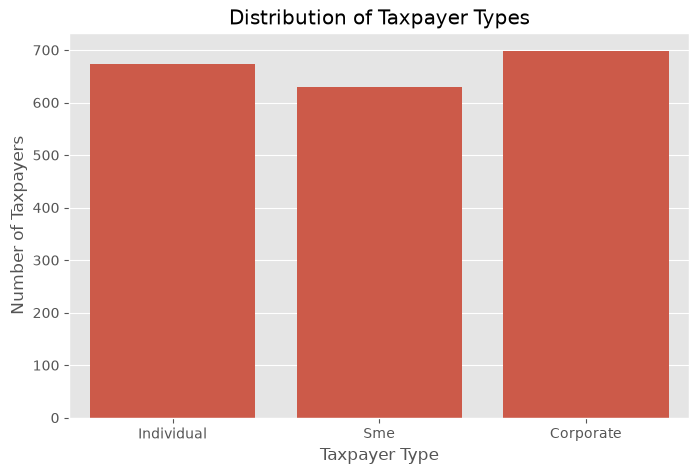

In [7]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='taxpayer_type')

plt.title("Distribution of Taxpayer Types")
plt.xlabel("Taxpayer Type")
plt.ylabel("Number of Taxpayers")

plt.show()

The chart shows the distribution of taxpayer categories in the dataset. SMEs constitute the largest proportion of taxpayers, followed by Individuals and Corporate organizations.

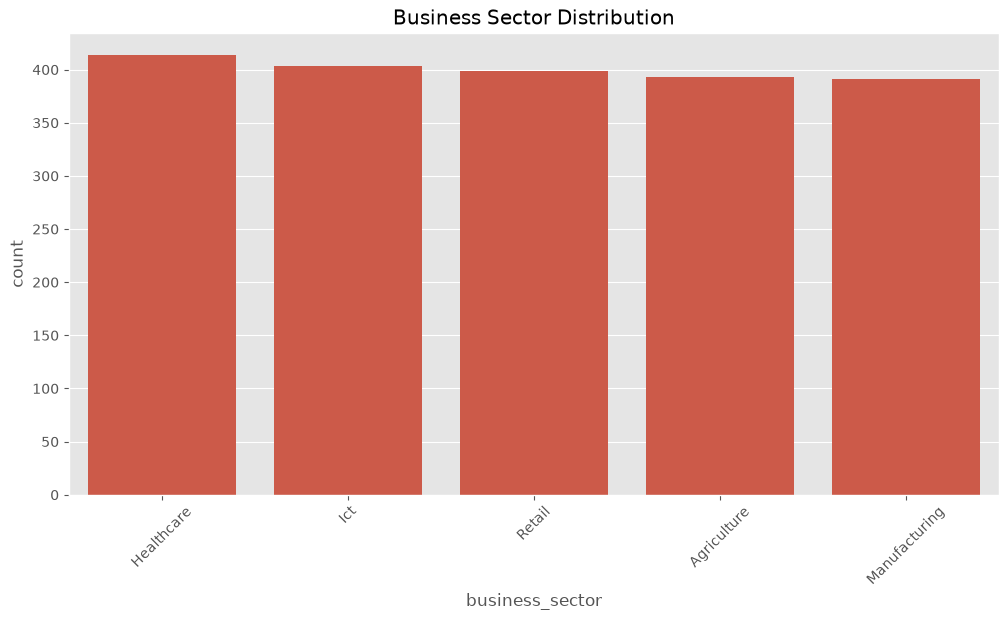

In [8]:
plt.figure(figsize=(12,6))

sns.countplot(data=df,
              x='business_sector',
              order=df['business_sector'].value_counts().index)

plt.xticks(rotation=45)

plt.title("Business Sector Distribution")

plt.show()

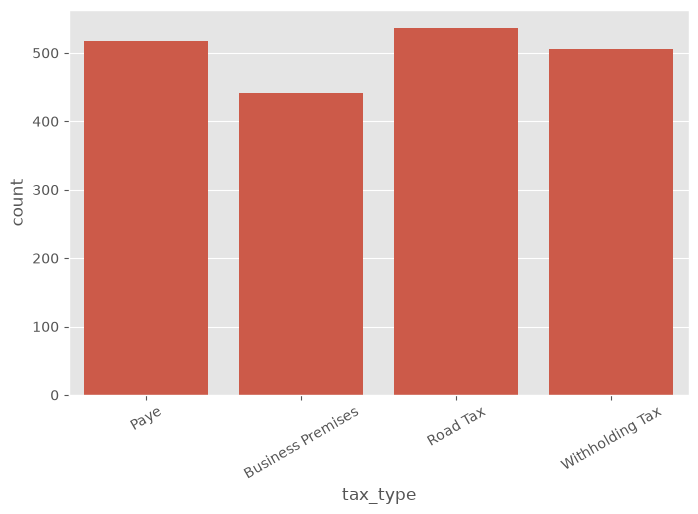

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,
              x='tax_type')

plt.xticks(rotation=30)

plt.show()

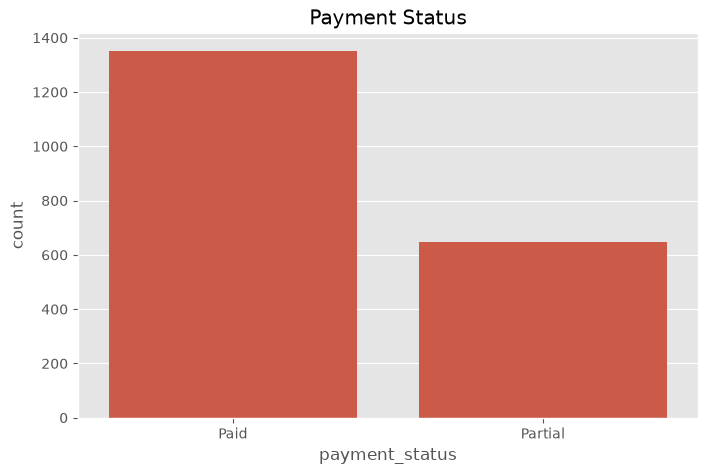

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,
              x='payment_status')

plt.title("Payment Status")

plt.show()

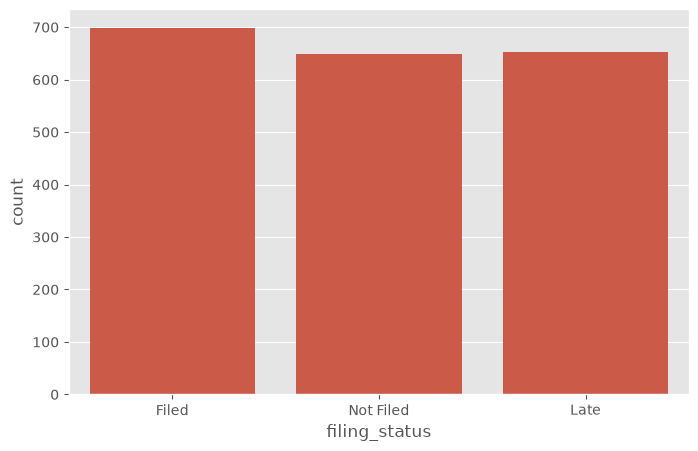

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,
              x='filing_status')

plt.show()

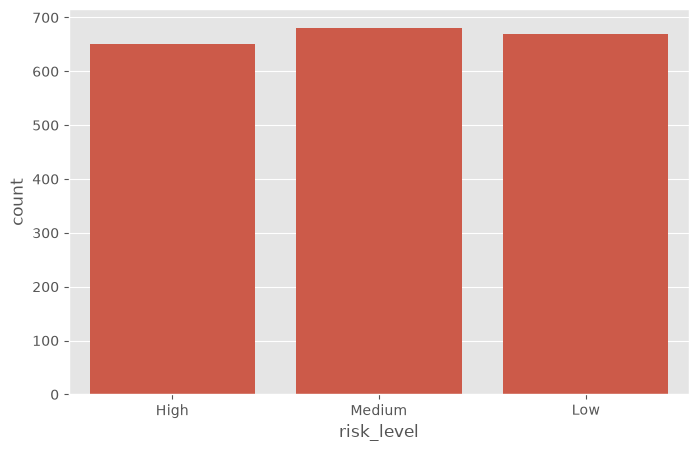

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,
              x='risk_level')

plt.show()

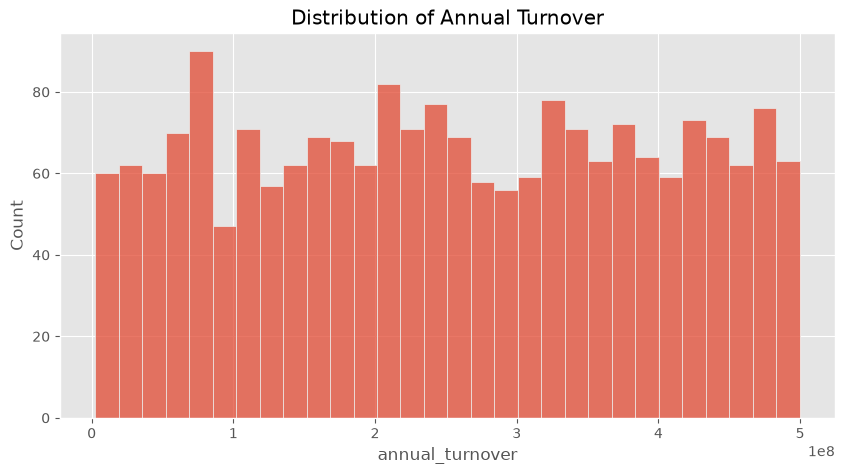

In [13]:
plt.figure(figsize=(10,5))

sns.histplot(df['annual_turnover'],
             bins=30)

plt.title("Distribution of Annual Turnover")

plt.show()

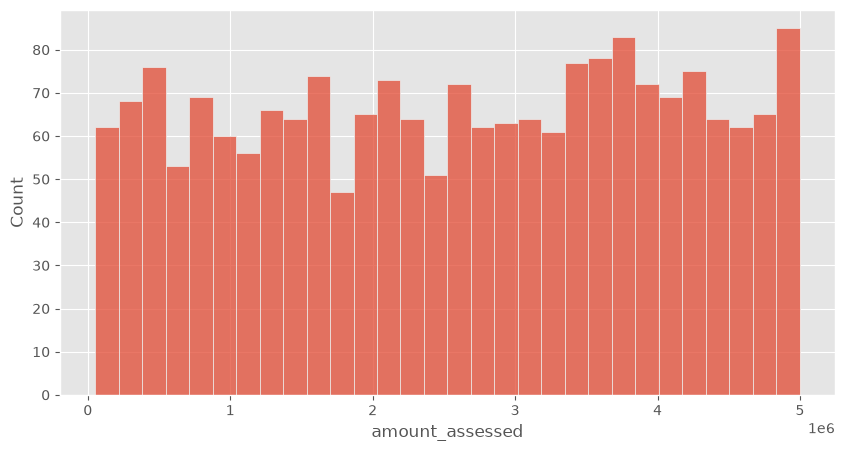

In [14]:
plt.figure(figsize=(10,5))

sns.histplot(df['amount_assessed'],
             bins=30)

plt.show()

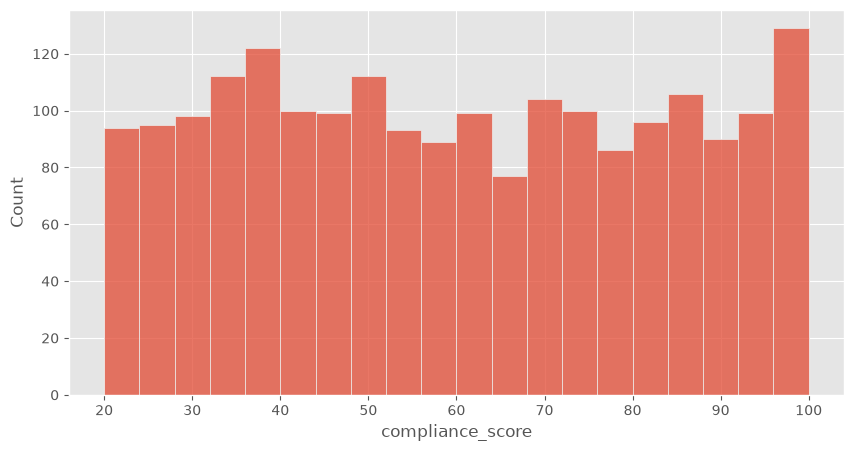

In [15]:
plt.figure(figsize=(10,5))

sns.histplot(df['compliance_score'],
             bins=20)

plt.show()

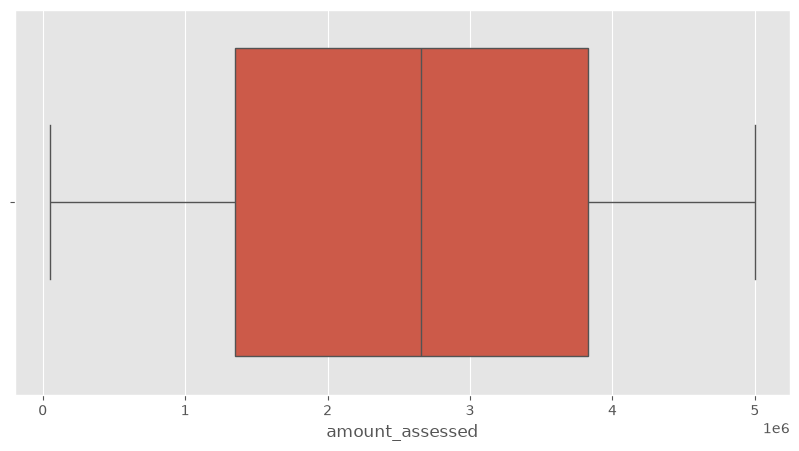

In [16]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df['amount_assessed'])

plt.show()

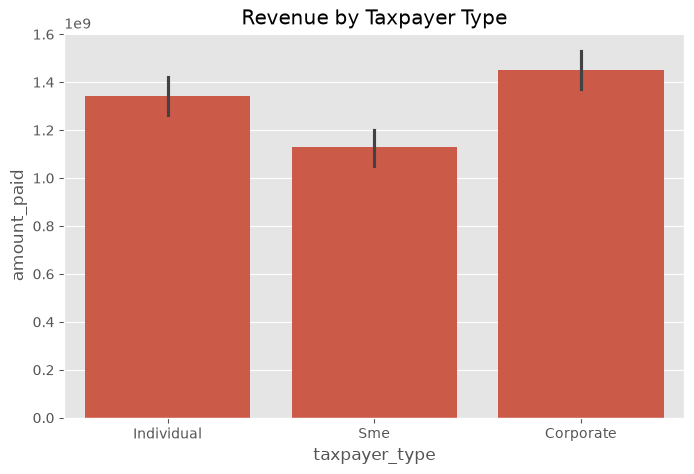

In [17]:
plt.figure(figsize=(8,5))

sns.barplot(data=df,
            x='taxpayer_type',
            y='amount_paid',
            estimator=np.sum)

plt.title("Revenue by Taxpayer Type")

plt.show()

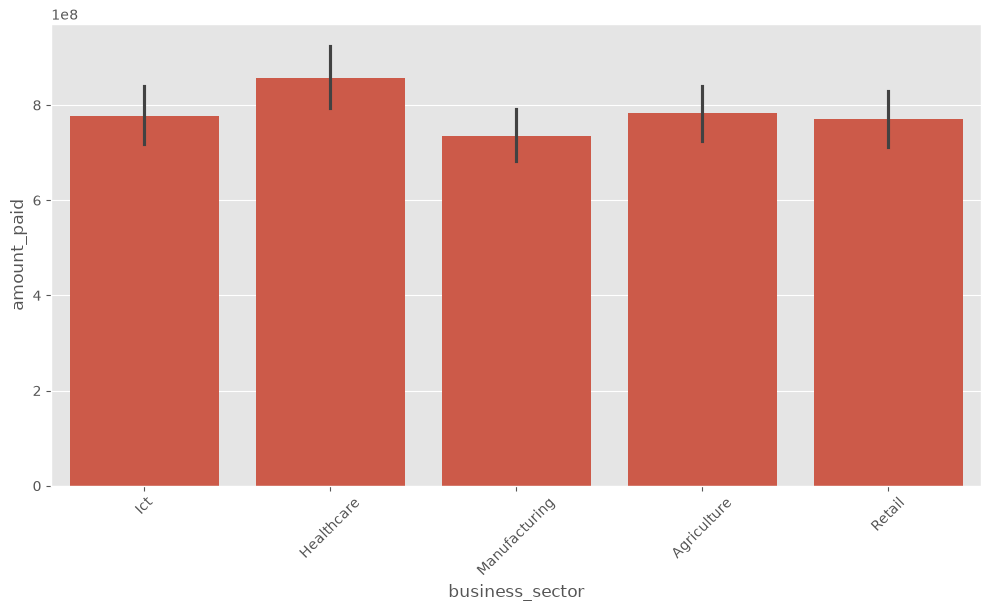

In [18]:
plt.figure(figsize=(12,6))

sns.barplot(data=df,
            x='business_sector',
            y='amount_paid',
            estimator=np.sum)

plt.xticks(rotation=45)

plt.show()

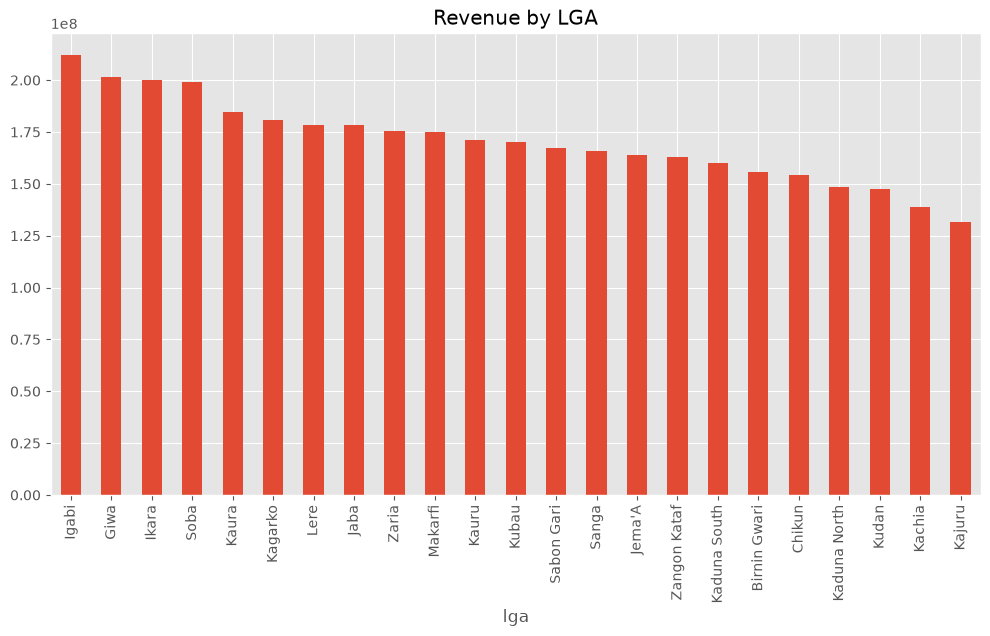

In [19]:
revenue = df.groupby("lga")["amount_paid"].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))

revenue.plot(kind="bar")

plt.title("Revenue by LGA")

plt.show()

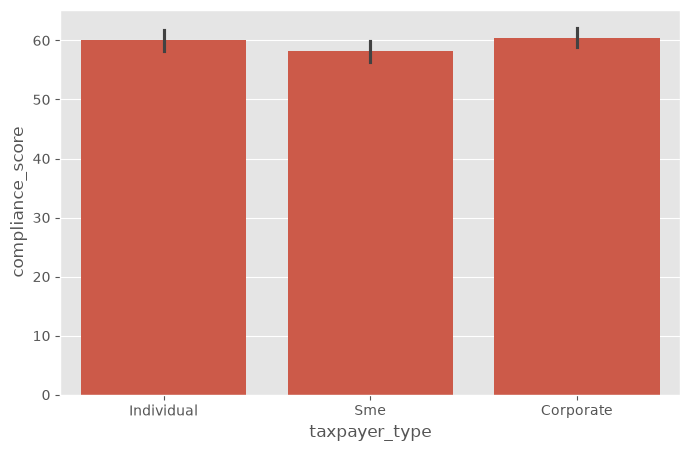

In [20]:
plt.figure(figsize=(8,5))

sns.barplot(data=df,
            x='taxpayer_type',
            y='compliance_score')

plt.show()

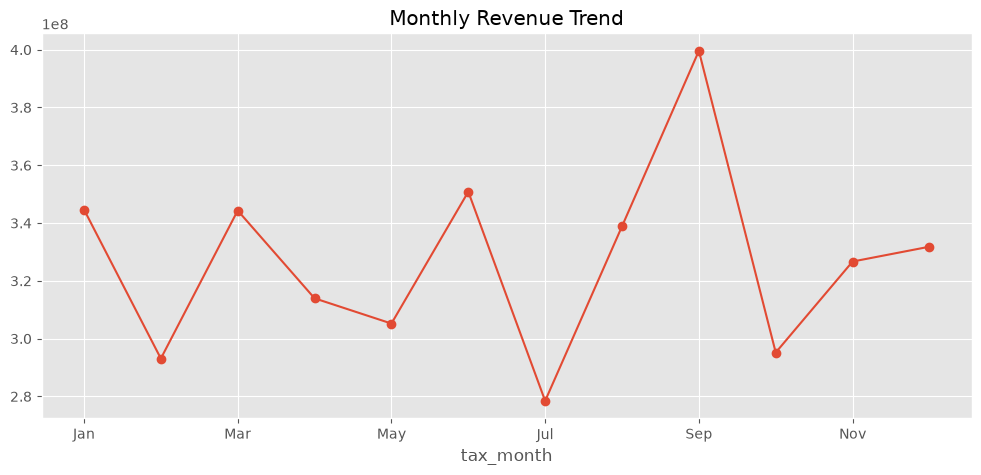

In [21]:
monthly = df.groupby("tax_month")["amount_paid"].sum()

monthly = monthly.reindex([
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
])

plt.figure(figsize=(12,5))

monthly.plot(marker="o")

plt.title("Monthly Revenue Trend")

plt.show()

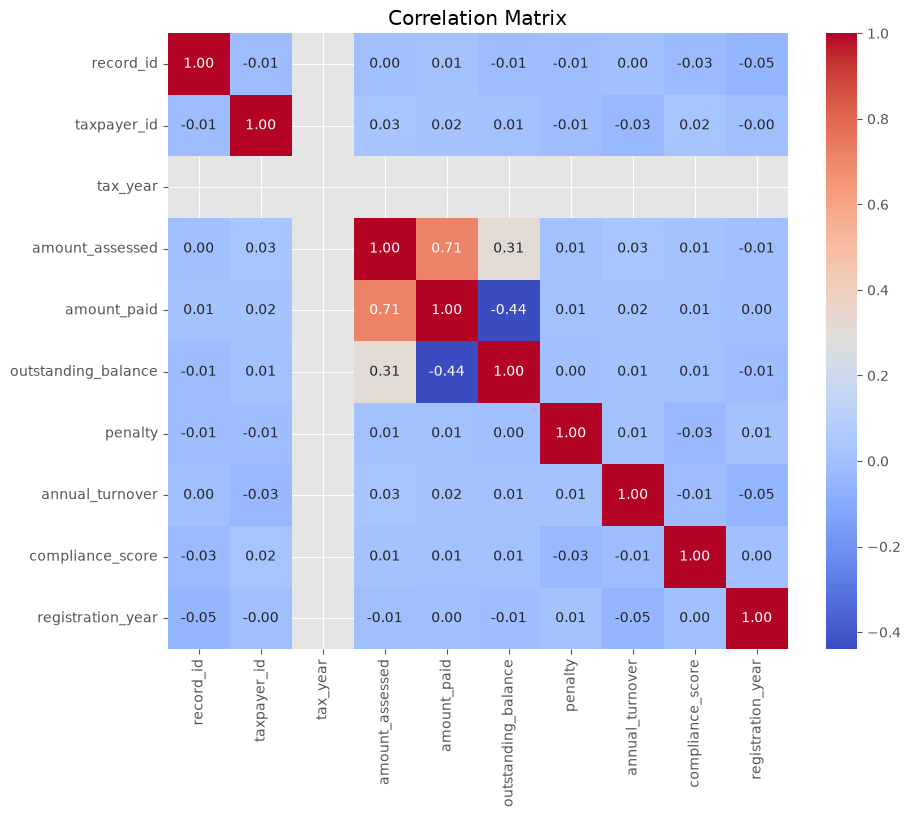

In [22]:
plt.figure(figsize=(10,8))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Matrix")

plt.show()

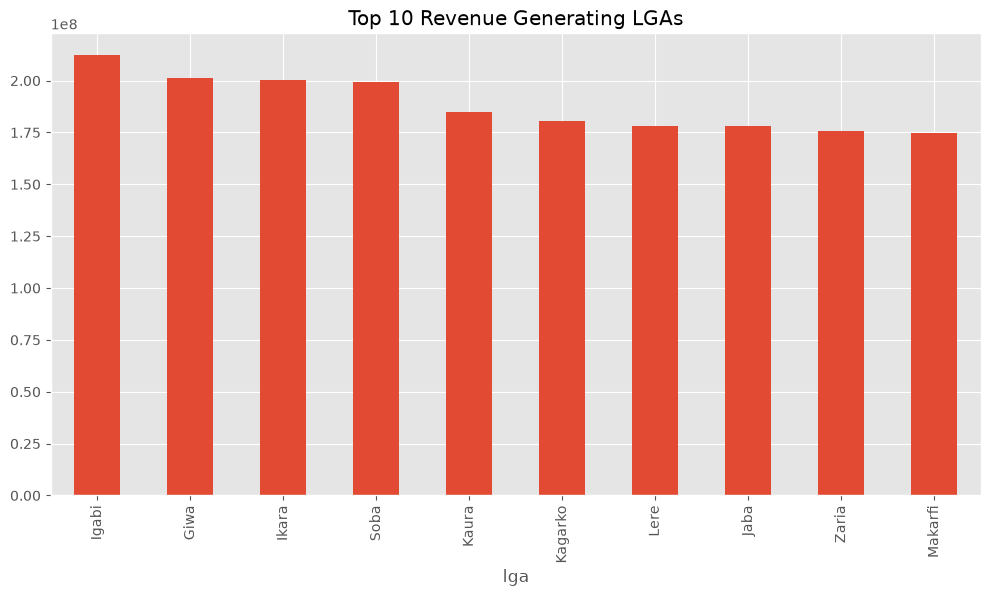

In [23]:
top_lga = df.groupby("lga")["amount_paid"] \
            .sum() \
            .sort_values(ascending=False) \
            .head(10)

plt.figure(figsize=(12,6))

top_lga.plot(kind="bar")

plt.title("Top 10 Revenue Generating LGAs")

plt.show()

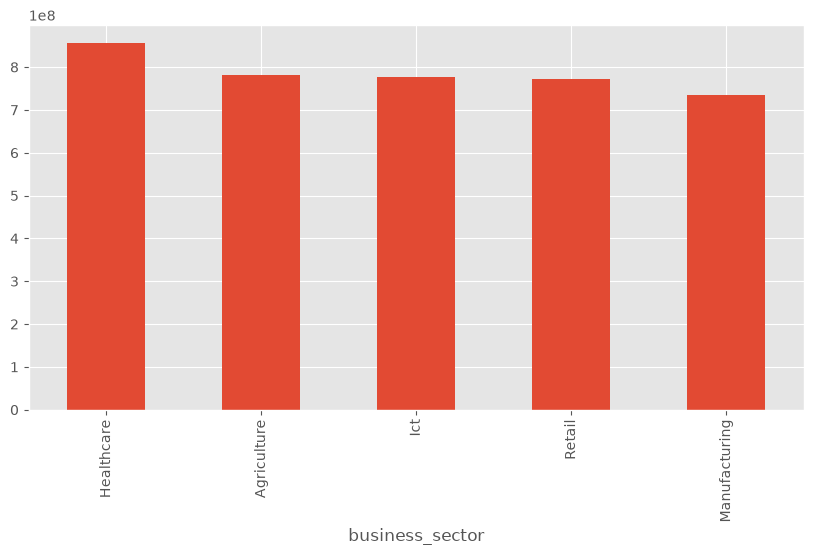

In [24]:
top_sector = df.groupby("business_sector")["amount_paid"] \
               .sum() \
               .sort_values(ascending=False)

top_sector.plot(kind="bar",
                figsize=(10,5))

plt.show()

In [25]:
kpis = {
    "Total Taxpayers": df["taxpayer_id"].nunique(),
    "Total Revenue": df["amount_paid"].sum(),
    "Total Assessed": df["amount_assessed"].sum(),
    "Outstanding Balance": df["outstanding_balance"].sum(),
    "Average Compliance Score": round(df["compliance_score"].mean(), 2),
    "Audit Rate (%)": round((df["audit_status"] == "Audited").mean() * 100, 2),
    "Payment Compliance (%)": round((df["payment_status"] == "Paid").mean() * 100, 2),
    "Filing Compliance (%)": round((df["filing_status"] == "Filed").mean() * 100, 2)
}

pd.DataFrame(kpis.items(), columns=["KPI", "Value"])

,KPI,Value
0,Total Taxpayers,6.690000e+02
1,Total Revenue,3.922694e+09
2,Total Assessed,5.180429e+09
3,Outstanding Balance,1.257735e+09
4,Average Compliance Score,5.962000e+01
5,Audit Rate (%),4.900000e+01
6,Payment Compliance (%),6.755000e+01
7,Filing Compliance (%),3.495000e+01
